Getting argo data and evaluating if there are enough profiles for the years

In [57]:
from argopy import DataFetcher
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.interpolate import PchipInterpolator
import random

In [3]:
def downloadArgoData(box):
    fetcher = DataFetcher(src='erddap').region(box)
    ds = fetcher.to_xarray()

    ds.to_netcdf('argo_florida_keys_raw.nc')
    print('Argo data downloaded')


Below we define our area of research, a bounding box around Florida Keys. We specify the data range from January 2010 to December 2023

In [4]:
box = [-83.5, -79.5, 23.5, 26.0, 0, 300, '2010-01', '2023-12']
downloadArgoData(box)

Argo data downloaded


In [16]:
def plotData(ds):
    ds=ds.copy()
    df = ds.to_dataframe().reset_index()
    lon_min, lon_max, lat_min, lat_max = -83.5, -79.5, 23.5, 26.0
    df['year'] = df['TIME'].dt.year


    years = sorted(df['year'].unique())
    n_years = len(years)

    cols = 4
    rows_for_years = int(np.ceil(n_years / cols))
    total_rows = 1 + rows_for_years

    fig = plt.figure(figsize=(18, 4 + rows_for_years * 4))
    gs = fig.add_gridspec(total_rows, cols, hspace=0.35, wspace=0.3)

    ax_main = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
    ax_main.add_feature(cfeature.LAND, facecolor='lightgray')
    ax_main.add_feature(cfeature.COASTLINE)
    ax_main.add_feature(cfeature.BORDERS, linestyle=':')

    scatter = ax_main.scatter(df['LONGITUDE'], df['LATITUDE'], 
                            c=df['TIME'].dt.year, cmap='viridis', 
                            s=15, alpha=0.7, transform=ccrs.PlateCarree())

    ax_main.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                [lat_min, lat_min, lat_max, lat_max, lat_min],
                color='red', linestyle='--', transform=ccrs.PlateCarree(), linewidth=2, label='Study Area')

    ax_main.set_extent([-85, -78, 22, 28])
    ax_main.set_title(f"All Years Combined - {len(df)} Total Profiles (2010-2023)", fontsize=14, fontweight='bold')
    ax_main.legend(loc='upper right')
    cbar = plt.colorbar(scatter, ax=ax_main, label='Year', shrink=0.8)

    for idx, year in enumerate(years):
        row = 1 + idx // cols
        col = idx % cols
        
        ax_year = fig.add_subplot(gs[row, col], projection=ccrs.PlateCarree())
        
        df_year = df[df['year'] == year]
        year_count = len(df_year)
        
        ax_year.add_feature(cfeature.LAND, facecolor='lightgray')
        ax_year.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax_year.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
        
        ax_year.scatter(df_year['LONGITUDE'], df_year['LATITUDE'], 
                    c='steelblue', s=20, alpha=0.7, 
                    transform=ccrs.PlateCarree(), edgecolors='darkblue', linewidth=0.3)
        
        ax_year.plot([lon_min, lon_max, lon_max, lon_min, lon_min],
                [lat_min, lat_min, lat_max, lat_max, lat_min],
                color='red', linestyle='--', transform=ccrs.PlateCarree(), linewidth=1)
        
        ax_year.set_extent([-85, -78, 22, 28])
        ax_year.set_title(f"{year}: {year_count} Profiles", fontsize=11, fontweight='bold')
        ax_year.set_xlabel('Longitude', fontsize=9)
        ax_year.set_ylabel('Latitude', fontsize=9)

    for idx in range(n_years, rows_for_years * cols):
        row = 1 + idx // cols
        col = idx % cols
        ax_unused = fig.add_subplot(gs[row, col])
        ax_unused.axis('off')

    plt.suptitle(f"Float Profile Trajectories - Argo Data (Florida Keys, 2010-2023)", 
                fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('argo_trajectories_by_year.png', dpi=300, bbox_inches='tight')
    print(f"\nVisualization saved to 'argo_trajectories_by_year.png'")
    print(f"Total subplots: 1 (all years) + {n_years} (individual years)")
    plt.show()

Load the downloaded data

In [46]:
filePath='argo_florida_keys_raw.nc'
ds=xr.open_dataset(filePath)

See one of the profiles

In [27]:
df = ds.to_dataframe().reset_index()

grouped = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])
first_key = next(iter(grouped.groups))
first_profile = grouped.get_group(first_key)

print('First profile key (PLATFORM_NUMBER, CYCLE_NUMBER):', first_key)
print(first_profile)
print('Number of pressure levels in first profile:', first_profile['TEMP'].count())
print('Number of pressure levels in first profile:', first_profile['PRES'].count())

First profile key (PLATFORM_NUMBER, CYCLE_NUMBER): (3901987, 216)
       N_POINTS  CYCLE_NUMBER DATA_MODE DIRECTION  PLATFORM_NUMBER  \
26556     26556           216         D         A          3901987   
26557     26557           216         D         A          3901987   
26558     26558           216         D         A          3901987   
26559     26559           216         D         A          3901987   
26560     26560           216         D         A          3901987   
...         ...           ...       ...       ...              ...   
26739     26739           216         D         A          3901987   
26740     26740           216         D         A          3901987   
26741     26741           216         D         A          3901987   
26742     26742           216         D         A          3901987   
26743     26743           216         D         A          3901987   

       POSITION_QC        PRES  PRES_ERROR  PRES_QC       PSAL  PSAL_ERROR  \
26556          

Plot the argo profiles yearwise, on the map

In [ ]:
plotData(ds)

Below function gives a better look at the data. We check total number of unique profiles available, depth profile overview, distribution of readings over the months and years, salinity, temperature distribution

In [59]:
def checkData(ds):
    df = ds.to_dataframe().reset_index()
    print(len(df))
    # 1. How many unique profiles do you actually have
    n_profiles = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']).ngroups
    print(f"Unique profiles: {n_profiles}")

    # 2. Depth coverage — what's the max pressure per profile
    max_depth = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].max()
    print(max_depth.describe())

    # See the distribution of all QC flags
    print("Temperature QC breakdown:")
    print(df['TEMP_QC'].value_counts())

    print("\nSalinity QC breakdown:")
    print(df['PSAL_QC'].value_counts())

    print(f"Profiles reaching 200m+: {(max_depth >= 200).sum()}")
    df['month'] = df['TIME'].dt.month
    df['year'] = df['TIME'].dt.year

    print(df.groupby(['year', 'month']).size().unstack())

    profile_depths = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].count()

    print("Depth levels per profile:")
    print(profile_depths.describe())
    print(f"\nMedian depth levels: {profile_depths.median():.0f}")
    print(f"Mode depth levels: {profile_depths.mode()[0]:.0f}")

    # # Distribution to see if it's consistent
    print("\nDistribution:")
    print(profile_depths.value_counts().sort_index())

    plt.figure(figsize=(10, 6))

    sns.histplot(df['PSAL'], kde=True, color='teal', bins=100)

    plt.title('Distribution of Practical Salinity (PSAL)')
    plt.xlabel('Salinity (psu)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('PSAL_distribution.png')

    
    plt.clf()
    
    sns.histplot(df['TEMP'], kde=True, color='teal', bins=100)

    plt.title('Distribution of temperature (TEMP)')
    plt.xlabel('Temp (C)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.3)
    plt.savefig('temp_distribution.png')

    temp_stats = df['TEMP'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
    print(temp_stats)

168881
Unique profiles: 1146
count    1146.000000
mean      297.338013
std        15.121387
min        31.000000
25%       299.000000
50%       299.959991
75%       300.000000
max       300.380005
Name: PRES, dtype: float64
Temperature QC breakdown:
TEMP_QC
1    168881
Name: count, dtype: int64

Salinity QC breakdown:
PSAL_QC
1    168881
Name: count, dtype: int64
Profiles reaching 200m+: 1140
month      1       2       3       4       5       6       7       8       9   \
year                                                                            
2010      NaN     NaN     NaN     NaN     NaN     NaN     NaN    31.0   219.0   
2011      NaN    93.0    94.0    32.0   251.0   263.0   114.0     NaN    31.0   
2012    449.0   899.0   898.0   448.0   140.0   423.0   508.0   299.0   298.0   
2013      NaN     NaN   150.0   300.0     NaN     NaN     NaN   288.0     NaN   
2014      NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2015      NaN   255.0     NaN     NaN

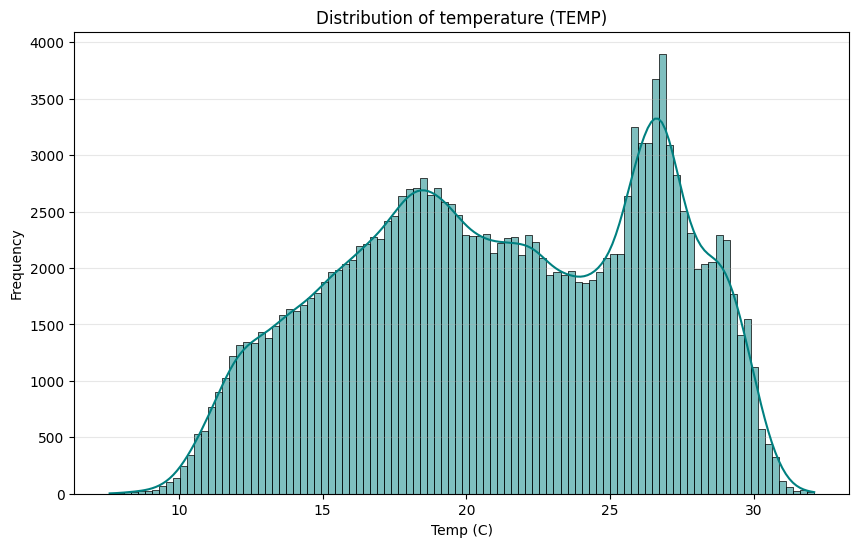

In [60]:
checkData(ds)

The data is sparse for the years 2010 to 2018. We need to consider the data distribution for the train/val/test split.

Moving on, we start preparing our data. 

In [47]:
def prepareData(ds):
    df = ds.to_dataframe().reset_index()
    print(f"Profiles before filtering: {df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']).ngroups}")    
    # Limit to upper 300m
    df = df[df['PRES'] <= 300]

    # Drop profiles with too few depth levels
    MIN_DEPTHS = 25
    profile_counts = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].count()
    valid_idx = profile_counts[profile_counts >= MIN_DEPTHS].index
    df = df.set_index(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    df = df[df.index.isin(valid_idx)].reset_index()

    # Drop profiles not reaching 200m
    profile_max_depth = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].max()
    deep_idx = profile_max_depth[profile_max_depth >= 200].index
    df = df.set_index(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    df = df[df.index.isin(deep_idx)].reset_index()

    # Drop physical outliers
    df = df[(df['TEMP'] > -2) & (df['TEMP'] < 35)]
    df = df[(df['PSAL'] > 30) & (df['PSAL'] < 38)]

    print(f"Profiles after filtering: {df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']).ngroups}")
    
    return df

In [48]:
df=prepareData(ds)

Profiles before filtering: 1146
Profiles after filtering: 1140


Next, we take a look at the depth resolution of the profiles. The plan is to drop low depth resolution profiles

In [49]:

depth_counts = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].count()

fine   = depth_counts[depth_counts >= 100]   # 2m resolution floats
coarse = depth_counts[(depth_counts >= 25) & (depth_counts < 100)]  # 10m floats
drop   = depth_counts[depth_counts < 25]     # too shallow, drop

print(f"Fine resolution (keep):   {len(fine)} profiles")
print(f"Coarse resolution (keep, interpolates ok): {len(coarse)} profiles")
print(f"Too shallow (drop):       {len(drop)} profiles")

Fine resolution (keep):   1072 profiles
Coarse resolution (keep, interpolates ok): 68 profiles
Too shallow (drop):       0 profiles


Luckily, the few profile that were present in the low count were filtered out in the prepareData step itself

In [50]:
print("TEMP NaN analysis:")
print(f"  Total NaN values: {df['TEMP'].isna().sum()}")
print(f"  Total rows: {len(df)}")
print(f"  NaN %: {df['TEMP'].isna().mean()*100:.2f}%")

print("\nPSAL NaN analysis:")
print(f"  Total NaN values: {df['PSAL'].isna().sum()}")
print(f"  Total rows: {len(df)}")
print(f"  NaN %: {df['PSAL'].isna().mean()*100:.2f}%")

print("\nPRES NaN analysis:")
print(f"  Total NaN values: {df['PRES'].isna().sum()}")

# How many profiles have at least one NaN
profiles_with_nan_temp = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['TEMP'].apply(lambda x: x.isna().any())
print(f"\nProfiles with at least one NaN TEMP: {profiles_with_nan_temp.sum()} / {len(profiles_with_nan_temp)}")

profiles_with_nan_psal = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PSAL'].apply(lambda x: x.isna().any())
print(f"Profiles with at least one NaN PSAL: {profiles_with_nan_psal.sum()} / {len(profiles_with_nan_psal)}")

TEMP NaN analysis:
  Total NaN values: 0
  Total rows: 168517
  NaN %: 0.00%

PSAL NaN analysis:
  Total NaN values: 0
  Total rows: 168517
  NaN %: 0.00%

PRES NaN analysis:
  Total NaN values: 0

Profiles with at least one NaN TEMP: 0 / 1140
Profiles with at least one NaN PSAL: 0 / 1140


Do not use the below interpolate_profile function. There is the improved one, a few cells below. Use that

In [ ]:

DEPTH_GRID = np.arange(2, 302, 2)  # 0 to 300m in 2m steps 

def interpolate_profile(PRES, TEMP, PSAL):
    """
    Interpolate a single Argo profile to fixed depth grid.
    Returns (temp_interp, psal_interp) or None if too sparse.
    """
    # Sort by pressure (depth)
    sort_idx = np.argsort(PRES)
    PRES, TEMP, PSAL = PRES[sort_idx], TEMP[sort_idx], PSAL[sort_idx]
    
    # Need enough points to interpolate
    if len(PRES) < 5:
        return None
    
    try:
        f_temp = interp1d(PRES, TEMP, kind='pchip', 
                          bounds_error=False, fill_value=np.nan)
        f_psal = interp1d(PRES, PSAL, kind='pchip',
                          bounds_error=False, fill_value=np.nan)
        
        temp_interp = f_temp(DEPTH_GRID)
        psal_interp = f_psal(DEPTH_GRID)
        
        # Reject if more than 20% of grid is NaN (profile too shallow)
        if np.sum(np.isnan(temp_interp)) > 0.1 * len(DEPTH_GRID):
            return None
            
        return temp_interp, psal_interp
    except:
        return None



After interpolation, we found some unusual trends. We saw that there were a large chunk of NaN values closer to the surface. This was because we started the depth grid from 0 m while most floats' minimum depth was more than 1 m. So we modified out interpolation range to start from 2m.
As we looked at the minimum depths, we found 1 anomaly. 1 profile's minimum depth was 236 m. This profile is not of much use to us because it has no data for depth between 2 to 236 m. 

In [ ]:
min_depth_per_profile = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].min()
print(min_depth_per_profile.describe())
print(min_depth_per_profile.value_counts().head(10))

count    1140.000000
mean        1.626697
std         7.150158
min         0.160000
25%         1.000000
50%         1.040000
75%         1.120000
max       236.399994
Name: PRES, dtype: float64
PRES
1.04    227
1.00    217
1.08    145
0.96    109
1.12     86
1.16     60
0.48     55
0.44     33
2.00     19
1.20     15
Name: count, dtype: int64


We ran the below code to have a closer look at the anomalous profile

In [44]:
min_depth_per_profile = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].min()
outlier = min_depth_per_profile[min_depth_per_profile > 200]
print(outlier)

platform, cycle = outlier.index[0]
profile_data = df[(df['PLATFORM_NUMBER'] == platform) & (df['CYCLE_NUMBER'] == cycle)]
print(profile_data[['PRES', 'TEMP', 'PSAL']].sort_values('PRES'))
print(f"\nPlatform: {platform}, Cycle: {cycle}")
print(f"Number of depth measurements: {len(profile_data)}")
print(f"Min depth: {profile_data['PRES'].min()}")
print(f"Max depth: {profile_data['PRES'].max()}")

PLATFORM_NUMBER  CYCLE_NUMBER
4903236          150             236.399994
Name: PRES, dtype: float32
             PRES       TEMP       PSAL
63196  236.399994  19.105000  36.609020
63197  237.960007  19.086000  36.606850
63198  239.960007  19.040001  36.600941
63199  242.000000  19.017000  36.596710
63200  244.039993  19.002001  36.595921
63201  246.039993  18.952000  36.589340
63202  247.919998  18.945999  36.587410
63203  249.919998  18.937000  36.586182
63204  251.880005  18.910000  36.586029
63205  253.960007  18.862000  36.593922
63206  255.960007  18.792000  36.589371
63207  257.959991  18.681999  36.573540
63208  260.000000  18.625999  36.565811
63209  262.000000  18.534000  36.554741
63210  264.000000  18.445000  36.542221
63211  265.959991  18.346001  36.529789
63212  268.000000  18.259001  36.530548
63213  270.000000  18.091999  36.498791
63214  271.959991  18.049999  36.490131
63215  274.000000  18.024000  36.484760
63216  276.000000  18.007999  36.482689
63217  277.959991  

So we remove it

In [ ]:
min_depth_per_profile = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].min()
valid_surface = min_depth_per_profile[min_depth_per_profile <= 50].index
df = df.set_index(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])
df = df[df.index.isin(valid_surface)].reset_index()
print(f"Profiles remaining: {df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']).ngroups}")

Profiles remaining: 1139


In [53]:
min_depth_per_profile = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].min()
outlier = min_depth_per_profile[min_depth_per_profile > 50]
print(len(outlier))



0


We take a spot look at a few profiles before interpolation for a before-after comparision. Here we collect a sample before interpolation

In [58]:
depth_counts = df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])['PRES'].count()

fine   = depth_counts[depth_counts >= 100]   
coarse = depth_counts[(depth_counts >= 25) & (depth_counts < 100)]  

fine_keys = fine.index.tolist()
coarse_keys = coarse.index.tolist()

sample_fine = random.sample(fine_keys, min(2, len(fine_keys)))
sample_coarse = random.sample(coarse_keys, min(2, len(coarse_keys)))

all_samples = {'Fine': sample_fine, 'Coarse': sample_coarse}

We improved our interpolate_profile function

In [54]:
def interpolate_profile(PRES, TEMP, PSAL):
    sort_idx = np.argsort(PRES)
    PRES, TEMP, PSAL = PRES[sort_idx], TEMP[sort_idx], PSAL[sort_idx]

    if len(PRES) < 5:
        return None

    try:
        f_temp = PchipInterpolator(PRES, TEMP, extrapolate=False)
        f_psal = PchipInterpolator(PRES, PSAL, extrapolate=False)

        temp_interp = f_temp(DEPTH_GRID)
        psal_interp = f_psal(DEPTH_GRID)

        first_valid_temp = TEMP[0]
        first_valid_psal = PSAL[0]
        temp_interp[np.isnan(temp_interp) & (DEPTH_GRID < PRES[0])] = first_valid_temp
        psal_interp[np.isnan(psal_interp) & (DEPTH_GRID < PRES[0])] = first_valid_psal

        last_valid_temp = TEMP[-1]
        last_valid_psal = PSAL[-1]
        temp_interp[np.isnan(temp_interp) & (DEPTH_GRID > PRES[-1])] = last_valid_temp
        psal_interp[np.isnan(psal_interp) & (DEPTH_GRID > PRES[-1])] = last_valid_psal

        if np.sum(np.isnan(temp_interp)) > 0.1 * len(DEPTH_GRID):
            return None

        return temp_interp, psal_interp
    except:
        return None


Runner code for interpolation

In [55]:
# Apply to all profiles
profiles = []
for (PLATFORM, CYCLE), group in df.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']):
    result = interpolate_profile(
        group['PRES'].values, 
        group['TEMP'].values, 
        group['PSAL'].values
    )
    if result is not None:
        temp_interp, psal_interp = result
        profiles.append({
            'PLATFORM': PLATFORM,
            'CYCLE': CYCLE,
            'LAT': group['LATITUDE'].iloc[0],
            'LON': group['LONGITUDE'].iloc[0],
            'DATE': group['TIME'].iloc[0],
            'TEMP': temp_interp,   
            'PSAL': psal_interp   
        })

print(len(profiles))
temp_array = np.stack([p['TEMP'] for p in profiles])  # (N, 151)
psal_array = np.stack([p['PSAL'] for p in profiles])  # (N, 151)

# NaN analysis
print("TEMP NaN analysis:")
print(f"  Total NaN values: {np.isnan(temp_array).sum()}")
print(f"  Profiles with any NaN: {np.isnan(temp_array).any(axis=1).sum()}")
print(f"  Profiles with all NaN: {np.isnan(temp_array).all(axis=1).sum()}")
print(f"  NaN % per depth level (mean across profiles):")

nan_per_depth = np.isnan(temp_array).mean(axis=0) * 100
print(f"    0-50m:    {nan_per_depth[:25].mean():.1f}%")
print(f"    50-150m:  {nan_per_depth[25:75].mean():.1f}%")
print(f"    150-300m: {nan_per_depth[75:].mean():.1f}%")

print("\nPSAL NaN analysis:")
print(f"  Total NaN values: {np.isnan(psal_array).sum()}")
print(f"  Profiles with any NaN: {np.isnan(psal_array).any(axis=1).sum()}")

1139
TEMP NaN analysis:
  Total NaN values: 0
  Profiles with any NaN: 0
  Profiles with all NaN: 0
  NaN % per depth level (mean across profiles):
    0-50m:    0.0%
    50-150m:  0.0%
    150-300m: 0.0%

PSAL NaN analysis:
  Total NaN values: 0
  Profiles with any NaN: 0


Before and after comparison of random profiles to see validate interpolation

In [ ]:
import pandas as pd
import numpy as np

for category, keys in all_samples.items():
    print(f"\n{'='*85}")
    print(f" CATEGORY: {category.upper()} ")
    print(f"{'='*85}")
    
    for (plat, cyc) in keys:
        # 1. Get the original raw data for this specific dive
        raw_group = df[(df['PLATFORM_NUMBER'] == plat) & (df['CYCLE_NUMBER'] == cyc)].sort_values('PRES')
        
        # 2. Retrieve the interpolated result from your 'profiles' list
        interp_res = next((p for p in profiles if p['PLATFORM'] == plat and p['CYCLE'] == cyc), None)
        
        if interp_res is None:
            print(f"Profile {plat}_{cyc} failed the 10% NaN threshold and was skipped.")
            continue

        print(f"\n>>> Profile: Platform {plat} | Cycle {cyc}")
        print(f"Raw Counts: {len(raw_group)} | Interpolated Grid: {len(DEPTH_GRID)} points")
        print("-" * 85)
        print(f"{'Depth (m)':<10} | {'Temp (C)':<15} | {'PSAL (psu)':<15} | {'Data Source'}")
        print("-" * 85)

        # Iterate through the entire depth grid to show the full transformation
        for i, target_depth in enumerate(DEPTH_GRID):
            i_temp = interp_res['TEMP'][i]
            i_psal = interp_res['PSAL'][i]
            
            # Check if a raw measurement exists within 0.5m of this grid point
            # This helps us identify which points are original vs calculated
            closest_raw = raw_group[(raw_group['PRES'] - target_depth).abs() < 0.5]
            
            if not closest_raw.empty:
                source = f"MEASURED ({closest_raw['PRES'].values[0]:.1f}m)"
                # Display the actual raw values to verify Pchip hits the nodes
                disp_t, disp_s = closest_raw['TEMP'].values[0], closest_raw['PSAL'].values[0]
            else:
                source = "--- [INTERPOLATED] ---"
                disp_t, disp_s = i_temp, i_psal

            # Print the row (limiting to every 2nd or 3rd for very long lists if needed, 
            # but here we show the full logic)
            print(f"{target_depth:<10.1f} | {disp_t:<15.4f} | {disp_s:<15.4f} | {source}")

            # Safety break to prevent infinite terminal scrolling if testing many profiles
            if i > 50: 
                print("... [truncated: first 100m shown] ...")
                break


 CATEGORY: FINE 

>>> Profile: Platform 4903278 | Cycle 110
Raw Counts: 155 | Interpolated Grid: 151 points
-------------------------------------------------------------------------------------
Depth (m)  | Temp (C)        | PSAL (psu)      | Data Source
-------------------------------------------------------------------------------------
0.0        | 26.9160         | 35.9380         | --- [INTERPOLATED] ---
2.0        | 26.9100         | 35.9370         | MEASURED (2.0m)
4.0        | 26.8880         | 35.9330         | MEASURED (4.0m)
6.0        | 26.7840         | 35.9340         | MEASURED (6.0m)
8.0        | 26.7170         | 35.9240         | MEASURED (8.0m)
10.0       | 26.7090         | 35.9230         | MEASURED (10.0m)
12.0       | 26.7010         | 35.9240         | MEASURED (12.0m)
14.0       | 26.6930         | 35.9240         | MEASURED (14.0m)
16.0       | 26.6860         | 35.9240         | MEASURED (16.0m)
18.0       | 26.6800         | 35.9260         | MEASURED (18.